# Exercise 5.2: Local Evaluation — Error Analysis

This notebook performs systematic error analysis and local evaluation
of our best model (Experiment L: RoBERTa-large verbalizer) on the
official dev set.

**Contents:**
1. Error Analysis — manual inspection of failure modes (FN/FP)
2. Baseline comparison — cross-tabulate our model vs baseline predictions
3. Confusion matrix & precision–recall curves
4. Ablation: threshold sensitivity analysis
5. Per-keyword / per-category breakdown
6. Error length & confidence analysis

In [1]:
import os
import sys
import json
import logging
import textwrap
import gc

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, roc_curve, roc_auc_score,
)
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
from utils.data import load_data_with_keyword, load_data_categories, PCL_CATEGORIES
from utils.pcl_dataset import PCLVerbalizerDataset, PCLDataset
from utils.pcl_deberta import PCLVerbalizer, PCLDeBERTa, PoolingStrategy
from utils.feature_comb import FeatureComb
from utils.eval import evaluate
from utils.feature import extract_keyword_feature

SEED = 42
DATA_DIR = "data"
OUT_DIR = "out"
PARAMS_DIR = "exp/out"
MODEL_OUT_DIR = PARAMS_DIR
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_LENGTH = 256
BATCH_SIZE = 24

# Best Model
BEST_EXP_NAME = "L_verbalizer"
BEST_MODEL_NAME = "roberta-large"

# My Baseline/First Attempt
BASELINE_CLASSIFIER_EXP = "exp1"
BASELINE_CLASSIFIER_MODEL = "microsoft/deberta-v3-base"

torch.manual_seed(SEED)
np.random.seed(SEED)

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s:\t%(message)s")
LOG = logging.getLogger(__name__)
LOG.info(f"Device: {DEVICE}")

login = None
try:
    login = os.getlogin()
except Exception as e:
    LOG.warning(f"Could not get login name: {e}")
if login == "jc4423":
    LOG.info("Running on lab machines, changing caches and model out dir")
    os.environ["HF_HOME"] = "/vol/bitbucket/jc4423/.cache/huggingface"
    os.environ["TRANSFORMERS_CACHE"] = "/vol/bitbucket/jc4423/.cache/huggingface"
    os.environ["HF_DATASETS_CACHE"] = "/vol/bitbucket/jc4423/.cache/huggingface"
    os.environ["PIP_CACHE_DIR"] = "/vol/bitbucket/jc4423/.cache/pip"
    os.environ["XDG_CACHE_HOME"] = "/vol/bitbucket/jc4423/.cache"
    MODEL_OUT_DIR = "/vol/bitbucket/jc4423/models/"
    BASELINE_CLASSIFIER_MODEL_DIR = "out"           # exp1 saves locally to out/

os.makedirs(OUT_DIR, exist_ok=True)

2026-03-04 16:32:46,483 INFO:	Device: cuda
2026-03-04 16:32:46,485 WARNING:	Could not get login name: [Errno 6] No such device or address


## 1. Load Best Model & Generate Predictions

In [2]:
# --- Load best config ---
with open(os.path.join(PARAMS_DIR, f"exp_{BEST_EXP_NAME}_best_params.json")) as f:
    best_config = json.load(f)

BEST_THRESHOLD = best_config["best_threshold"]
TEMPLATE_IDX = best_config["template_idx"]
VERBALIZER_NAME = best_config["verbalizer"]

# --- Verbalizer setup ---
best_tokeniser = AutoTokenizer.from_pretrained(BEST_MODEL_NAME)

VERBALIZER_SETS = [
    ("Yes_No",     ["Yes"],  ["No"]),
    ("yes_no",     ["yes"],  ["no"]),
    ("True_False", ["True"], ["False"]),
    ("true_false", ["true"], ["false"]),
]

TEMPLATE_OPTIONS = [
    'Is the following text patronising or condescending? "{text}" Answer: {mask}',
    'Does the author of this text sound patronising or condescending? "{text}" Answer: {mask}',
    'Is this text talking down to people? "{text}" Answer: {mask}',
    'Does the following text contain patronising language? "{text}" Answer: {mask}',
]

verb_set = [v for v in VERBALIZER_SETS if v[0] == VERBALIZER_NAME][0]
pos_ids = [best_tokeniser.encode(w, add_special_tokens=False)[0] for w in verb_set[1]]
neg_ids = [best_tokeniser.encode(w, add_special_tokens=False)[0] for w in verb_set[2]]
template = TEMPLATE_OPTIONS[TEMPLATE_IDX]

print(f"Verbalizer: {VERBALIZER_NAME}")
print(f"Template:   {template}")
print(f"Threshold:  {BEST_THRESHOLD}")

2026-03-04 16:32:46,853 INFO:	HTTP Request: HEAD https://huggingface.co/roberta-large/resolve/main/config.json "HTTP/1.1 200 OK"
2026-03-04 16:32:46,855 WARNING:	Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-03-04 16:32:46,964 INFO:	HTTP Request: HEAD https://huggingface.co/roberta-large/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-04 16:32:47,062 INFO:	HTTP Request: GET https://huggingface.co/api/models/roberta-large/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-03-04 16:32:47,163 INFO:	HTTP Request: GET https://huggingface.co/api/models/FacebookAI/roberta-large/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-04 16:32:47,258 INFO:	HTTP Request: GET https://huggingface.co/api/models/roberta-large/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2

Verbalizer: true_false
Template:   Is this text talking down to people? "{text}" Answer: {mask}
Threshold:  0.275


In [3]:
best_model = PCLVerbalizer(
    pos_verbalizer_ids=pos_ids,
    neg_verbalizer_ids=neg_ids,
    model_name=BEST_MODEL_NAME,
    gradient_checkpointing=False,
    cache_dir="/vol/bitbucket/jc4423/.cache/huggingface" if login == "jc4423" else None,
).to(DEVICE)

best_state_dict = torch.load(
    os.path.join(MODEL_OUT_DIR, f"exp_{BEST_EXP_NAME}_best_model.pt"),
    map_location=DEVICE,
)
best_model.load_state_dict(best_state_dict)
best_model.eval()
LOG.info("Model loaded.")

2026-03-04 16:32:47,783 INFO:	HTTP Request: HEAD https://huggingface.co/roberta-large/resolve/main/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: roberta-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-04 16:32:52,115 INFO:	Verbalizer model loaded: RobertaForMaskedLM, n_pos=1, n_neg=1, pos_ids=[29225], neg_ids=[22303]
2026-03-04 16:32:52,117 INFO:	  backbone attr: .None, head attr: .None
2026-03-04 16:33:13,059 INFO:	Model loaded.


In [4]:
# Load dev data with keywords and categories for later analysis
_, dev_kw_df = load_data_with_keyword(DATA_DIR)
_, dev_cat_df = load_data_categories(DATA_DIR)

# Merge keyword + categories into one df
dev_df = dev_kw_df.copy()
for cat in PCL_CATEGORIES:
    dev_df[cat] = dev_cat_df[cat]

LOG.info(f"Dev set: {len(dev_df)} samples, {dev_df['binary_label'].sum()} positive")

dev_ds = PCLVerbalizerDataset(
    texts=dev_df["text"].tolist(),
    labels=dev_df["binary_label"].tolist(),
    max_length=MAX_LENGTH,
    tokeniser=best_tokeniser,
    template=template,
)
dev_loader = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False)

2026-03-04 16:33:13,861 INFO:	Dev set: 2093 samples, 199 positive
2026-03-04 16:33:14,476 WARNING:	Sample 1482: [MASK] token was truncated (text may be too long for max_length=256). Falling back to position 0.


In [5]:
best_model_results = evaluate(
    model=best_model,
    device=DEVICE,
    dataloader=dev_loader,
    threshold=BEST_THRESHOLD,
)

probs = best_model_results["probs"]
labels = best_model_results["labels"]
preds = best_model_results["preds"]

gc.collect()
torch.cuda.empty_cache()

In [6]:
# Attach predictions & scores to the DataFrame
dev_df = dev_df.copy()
dev_df["best_pred"] = preds
dev_df["score"] = probs
dev_df["correct"] = (dev_df["best_pred"] == dev_df["binary_label"]).astype(int)

# Classification buckets
dev_df["error_type"] = "TN"
dev_df.loc[(dev_df["binary_label"] == 1) & (dev_df["best_pred"] == 1), "error_type"] = "TP"
dev_df.loc[(dev_df["binary_label"] == 1) & (dev_df["best_pred"] == 0), "error_type"] = "FN"
dev_df.loc[(dev_df["binary_label"] == 0) & (dev_df["best_pred"] == 1), "error_type"] = "FP"

print(dev_df["error_type"].value_counts())
print(f"\nF1: {f1_score(labels, preds):.4f}")

error_type
TN    1779
TP     132
FP     115
FN      67
Name: count, dtype: int64

F1: 0.5919


## 2. Error Analysis — Manual Inspection

Inspect false positives and false negatives to understand failure modes.

In [7]:
def show_samples(df: pd.DataFrame, title: str, n: int = 10, sort_col: str = "score",
                 ascending: bool = True):
    """Pretty-print samples with their text, score, and metadata."""
    subset = df.sort_values(sort_col, ascending=ascending).head(n)
    print(f"\n{'='*80}")
    print(f" {title} (n={len(df)}, showing {min(n, len(df))})")
    print(f"{'='*80}")
    for i, (idx, row) in enumerate(subset.iterrows()):
        wrapped = textwrap.fill(row['text'], width=90, initial_indent='  ', subsequent_indent='  ')
        print(f"\n[{i+1}] par_id={idx} | keyword={row['keyword']} | "
              f"score={row['score']:.4f} | label={row['binary_label']}")
        print(wrapped)
    print()

In [8]:
fn_df = dev_df[dev_df["error_type"] == "FN"]
fp_df = dev_df[dev_df["error_type"] == "FP"]

# False Negatives: PCL samples the model missed (sorted by highest confidence wrong)
show_samples(fn_df, "FALSE NEGATIVES — PCL missed by model", n=15, sort_col="score", ascending=True)

# False Positives: Non-PCL samples the model incorrectly flagged (sorted by highest confidence wrong)
show_samples(fp_df, "FALSE POSITIVES — Non-PCL flagged by model", n=15, sort_col="score", ascending=False)


 FALSE NEGATIVES — PCL missed by model (n=67, showing 15)

[1] par_id=6234 | keyword=poor-families | score=0.0000 | label=1
  The World Health Organization did not give a reason for the increase in deaths , but a
  provincial health official in Sindh said that the disease hit areas where poor families
  did not vaccinate their children .

[2] par_id=10326 | keyword=poor-families | score=0.0000 | label=1
  A top health official said today that the government could consider subsidies to help
  poor families pay for healthy food -- or imposing taxes on unhealthy products -- if
  other efforts fail to encourage better eating habits among Hong Kong residents . Dr
  Regina Ching from the Health Department said such moves could be explored as a way to
  cut levels of chronic illnesses in the city , such ...

[3] par_id=7040 | keyword=poor-families | score=0.0000 | label=1
  Michael Gove 's recent suggestion that inadequate financial management skills among poor
  families are to blame for th

## 3. Baseline Comparison
Compare our model's predictions against the **classifier baseline** (exp1) `PCLDeBERTa` raw DeBERTa-v3-base fine-tuning.

In [16]:
gc.collect()
torch.cuda.empty_cache()

POOLING_MAP = {
    "cls": PoolingStrategy.CLS, "mean": PoolingStrategy.MEAN,
    "max": PoolingStrategy.MAX, "cls_mean": PoolingStrategy.CLS_MEAN,
}

with open(os.path.join(PARAMS_DIR, f"{BASELINE_CLASSIFIER_EXP}_best_params.json")) as f:
    bl_params = json.load(f) 

bl_threshold = bl_params["best_threshold"]
bl_tokeniser = AutoTokenizer.from_pretrained(BASELINE_CLASSIFIER_MODEL)

n_extra = 0
extra_feats = None

pooling = POOLING_MAP[bl_params["pooling"]]

model_bl = PCLDeBERTa(
    hidden_dim=bl_params["hidden_dim"],
    dropout_rate=bl_params.get("dropout_rate", 0.0),
    n_extra_features=n_extra,
    pooling=pooling,
    model_name=BASELINE_CLASSIFIER_MODEL,
    gradient_checkpointing=False,
).to(DEVICE)

sd = torch.load(os.path.join(PARAMS_DIR, f"{BASELINE_CLASSIFIER_EXP}_best_model.pt"), map_location=DEVICE)
model_bl.load_state_dict(sd)
model_bl.eval()

dev_ds = PCLDataset(
    texts=dev_kw_df["text"].tolist(),
    labels=dev_kw_df["binary_label"].tolist(),
    max_length=MAX_LENGTH,
    tokeniser=bl_tokeniser,
    extra_features=extra_feats,
)
loader = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False)
metrics = evaluate(model_bl, DEVICE, loader, threshold=bl_threshold)

LOG.info(f"Baseline {BASELINE_CLASSIFIER_EXP}: F1={metrics['f1']:.4f}, P={metrics['precision']:.4f}, "
            f"R={metrics['recall']:.4f} (threshold={bl_threshold:.3f})")

del model_bl
gc.collect(); torch.cuda.empty_cache()

bl_preds = metrics["preds"]
dev_df["baseline_clf_pred"] = bl_preds

2026-03-04 16:42:13,152 INFO:	HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-04 16:42:13,161 INFO:	HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-base/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/config.json "HTTP/1.1 200 OK"
2026-03-04 16:42:13,259 INFO:	HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-04 16:42:13,273 INFO:	HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-base/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-04 16:42:13,372 INFO:	HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-04 16:42:13,472 INFO:	HTTP Request: GET https://huggingface.co/api/model

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-04 16:42:20,194 INFO:	Backbone model loaded: 

In [19]:
best_correct = dev_df["correct"]
bl_correct = (dev_df["baseline_clf_pred"] == dev_df["binary_label"]).astype(int)

crosstab = pd.crosstab(
    pd.Categorical(dev_df["correct"].map({1: "Best Correct", 0: "Best Wrong"}),
                    categories=["Best Correct", "Best Wrong"]),
    pd.Categorical(bl_correct.map({1: f"{BASELINE_CLASSIFIER_EXP} Correct", 0: f"{BASELINE_CLASSIFIER_EXP} Wrong"}),
                    categories=[f"{BASELINE_CLASSIFIER_EXP} Correct", f"{BASELINE_CLASSIFIER_EXP} Wrong"]),
    margins=True,
)
print(f"\n{'='*60}")
print(f" Cross-tabulation: Best vs {BASELINE_CLASSIFIER_EXP}")
print(f"{'='*60}")
print(crosstab)

both_right = ((best_correct == 1) & (bl_correct == 1)).sum()
both_wrong = ((best_correct == 0) & (bl_correct == 0)).sum()
ours_only  = ((best_correct == 1) & (bl_correct == 0)).sum()
base_only  = ((best_correct == 0) & (bl_correct == 1)).sum()

print(f"\n  Both correct:\t{both_right}")
print(f"  Both wrong:\t{both_wrong}")
print(f"  Only best correct:\t{ours_only}")
print(f"  Only {BASELINE_CLASSIFIER_EXP} correct:\t{base_only}")

# Show examples where models disagree
ours_wins = dev_df[(best_correct == 1) & (bl_correct == 0)]
base_wins = dev_df[(best_correct == 0) & (bl_correct == 1)]
show_samples(ours_wins, f"BEST CORRECT, {BASELINE_CLASSIFIER_EXP} WRONG", n=8, sort_col="score", ascending=False)
show_samples(base_wins, f"{BASELINE_CLASSIFIER_EXP} CORRECT, BEST WRONG", n=8, sort_col="score", ascending=False)


 Cross-tabulation: Best vs exp1
col_0         exp1 Correct  exp1 Wrong   All
row_0                                       
Best Correct          1794         117  1911
Best Wrong              77         105   182
All                   1871         222  2093

  Both correct:	1794
  Both wrong:	105
  Only best correct:	117
  Only exp1 correct:	77

 BEST CORRECT, exp1 WRONG (n=117, showing 8)

[1] par_id=3861 | keyword=homeless | score=1.0000 | label=1
  In time , when the housing backlog for the low middle- and low-income families will have
  been significantly whittled down to manageable levels , the government can start looking
  at ways and means to bring these " lesser " Filipinos into the embrace of economic
  health -- and away from that malady called homelessness .

[2] par_id=5552 | keyword=vulnerable | score=1.0000 | label=1
  The Minister said a society 's measure of its humanity is how it treats its weakest and
  most vulnerable members .

[3] par_id=5252 | keyword=poor-famili

## 4. Confusion Matrix & Precision–Recall Curve

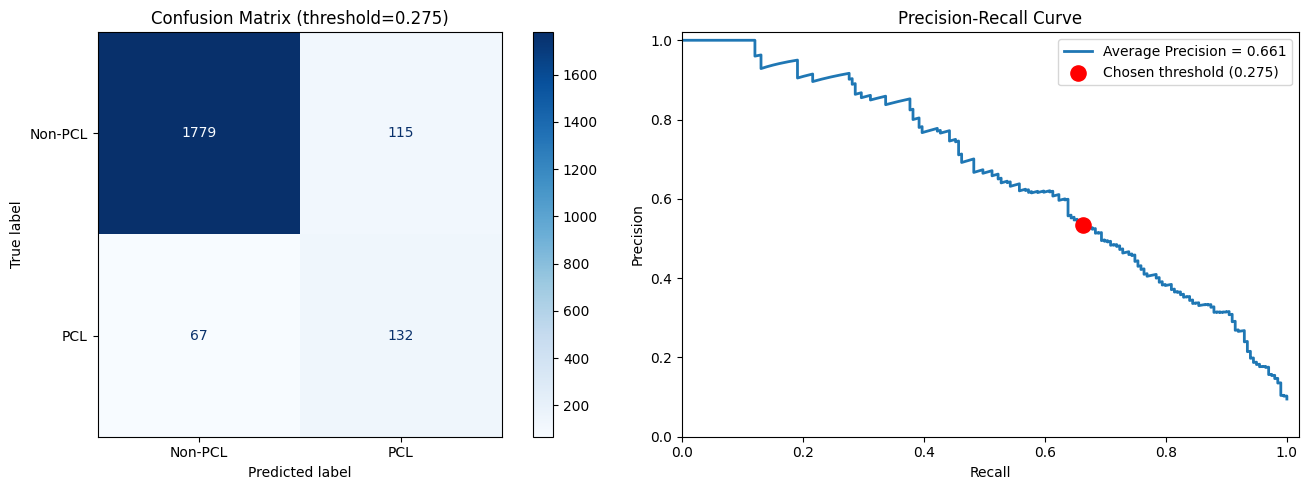

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non-PCL", "PCL"])
disp.plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title(f"Confusion Matrix (threshold={BEST_THRESHOLD:.3f})")

# --- Precision–Recall Curve ---
precision_arr, recall_arr, thresholds_pr = precision_recall_curve(labels, probs)
avg_p = average_precision_score(labels, probs)
axes[1].plot(recall_arr, precision_arr, linewidth=2, label=f"Average Precision = {avg_p:.3f}")

best_thresh_idx = np.argmin(np.abs(thresholds_pr - BEST_THRESHOLD))
axes[1].scatter([recall_arr[best_thresh_idx]], [precision_arr[best_thresh_idx]], s=120, c="red", zorder=5,
                label=f"Chosen threshold ({BEST_THRESHOLD:.3f})")

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()
axes[1].set_xlim(0, 1.02)
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/error_analysis_cm_pr.png", dpi=300)
plt.show()

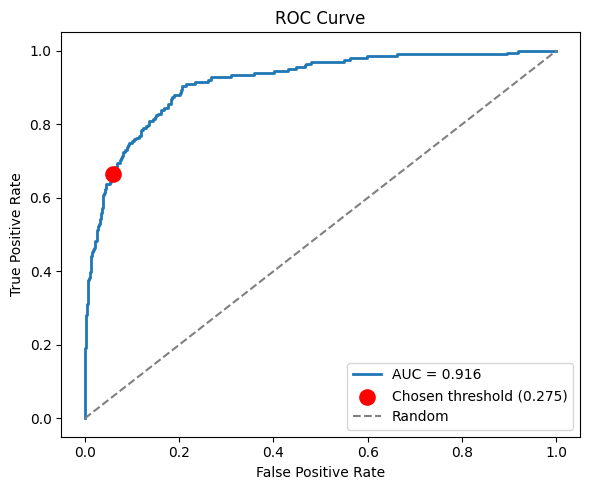

AUC-ROC:          0.9158
Average Precision: 0.6614


In [29]:
# --- ROC Curve ---
fpr, tpr, thresholds_roc = roc_curve(labels, probs)
auc = roc_auc_score(labels, probs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
best_thresh_idx = np.argmin(np.abs(thresholds_roc - BEST_THRESHOLD))
ax.scatter([fpr[best_thresh_idx]], [tpr[best_thresh_idx]], s=120, c="red", zorder=5,
                label=f"Chosen threshold ({BEST_THRESHOLD:.3f})")
ax.plot([0, 1], [0, 1], "--", color="grey", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/error_analysis_roc.png", dpi=300)
plt.show()

print(f"AUC-ROC:          {auc:.4f}")
print(f"Average Precision: {avg_p:.4f}")

## 5. Ablation: Threshold Sensitivity

Sweep thresholds to show F1/precision/recall trade-offs.

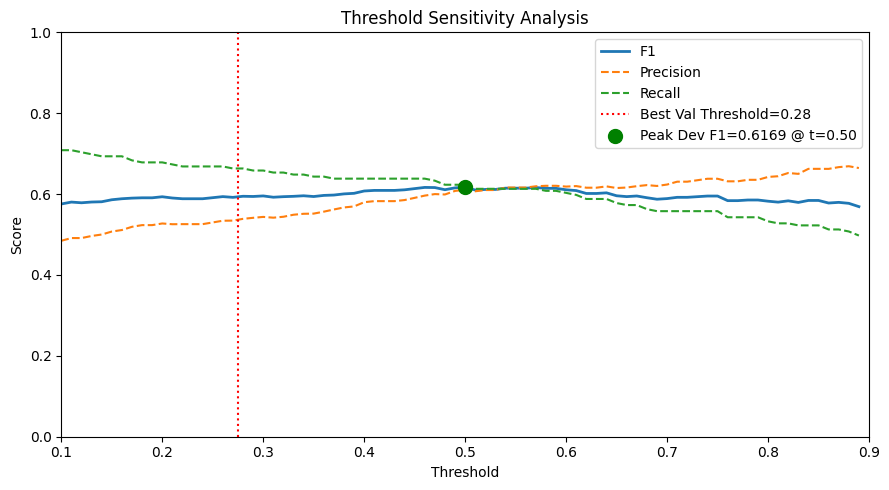

In [31]:
thresholds = np.arange(0.10, 0.90, 0.01)
f1s, precs, recs = [], [], []
for t in thresholds:
    p = (probs >= t).astype(int)
    f1s.append(f1_score(labels, p, zero_division=0))
    precs.append(precision_score(labels, p, zero_division=0))
    recs.append(recall_score(labels, p, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, f1s, label="F1", linewidth=2)
ax.plot(thresholds, precs, label="Precision", linewidth=1.5, linestyle="--")
ax.plot(thresholds, recs, label="Recall", linewidth=1.5, linestyle="--")
ax.axvline(x=BEST_THRESHOLD, color="red", linestyle=":", label=f"Best Val Threshold={BEST_THRESHOLD:.2f}")

best_sweep_idx = np.argmax(f1s)
ax.scatter([thresholds[best_sweep_idx]], [f1s[best_sweep_idx]], s=100, c="green", zorder=5,
           label=f"Peak Dev F1={f1s[best_sweep_idx]:.4f} @ t={thresholds[best_sweep_idx]:.2f}")

ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Sensitivity Analysis")
ax.legend()
ax.set_xlim(0.10, 0.90)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/error_analysis_threshold.png", dpi=300)
plt.show()

## 6. Per-Keyword Breakdown

Analyse performance by the **keyword** (vulnerable group) associated
with each paragraph (e.g. 'homeless', 'migrant', 'disabled').

In [34]:
kw_stats = []
for kw, group in dev_df.groupby("keyword"):
    n = len(group)
    n_pos = group["binary_label"].sum()
    if n_pos == 0:
        # Can't compute F1 for keyword with no positive samples
        kw_stats.append({"keyword": kw, "n": n, "n_pos": n_pos,
                         "f1": np.nan, "precision": np.nan, "recall": np.nan,
                         "fp": (group["error_type"] == "FP").sum(),
                         "fn": 0})
        continue
    f1 = f1_score(group["binary_label"], group["best_pred"], zero_division=0)
    prec = precision_score(group["binary_label"], group["best_pred"], zero_division=0)
    rec = recall_score(group["binary_label"], group["best_pred"], zero_division=0)
    kw_stats.append({"keyword": kw, "n": n, "n_pos": n_pos,
                     "f1": f1, "precision": prec, "recall": rec,
                     "fp": (group["error_type"] == "FP").sum(),
                     "fn": (group["error_type"] == "FN").sum()})

kw_df = pd.DataFrame(kw_stats).sort_values("n_pos", ascending=True)
print(kw_df.to_string(index=False))

      keyword   n  n_pos       f1  precision   recall  fp  fn
      migrant 206      5 0.727273   0.666667 0.800000   2   1
    immigrant 218      7 0.400000   0.666667 0.285714   1   5
      refugee 188     13 0.592593   0.571429 0.615385   6   5
     disabled 194     14 0.484848   0.421053 0.571429  11   6
        women 233     14 0.457143   0.380952 0.571429  13   6
   vulnerable 209     20 0.652174   0.576923 0.750000  11   5
     hopeless 217     26 0.553846   0.461538 0.692308  21   8
     homeless 212     29 0.593750   0.542857 0.655172  16  10
      in-need 226     33 0.769231   0.666667 0.909091  15   3
poor-families 190     38 0.519481   0.512821 0.526316  19  18


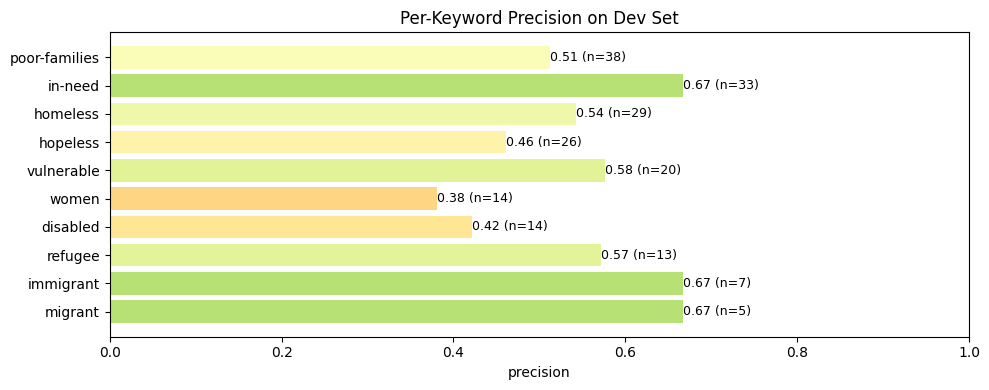

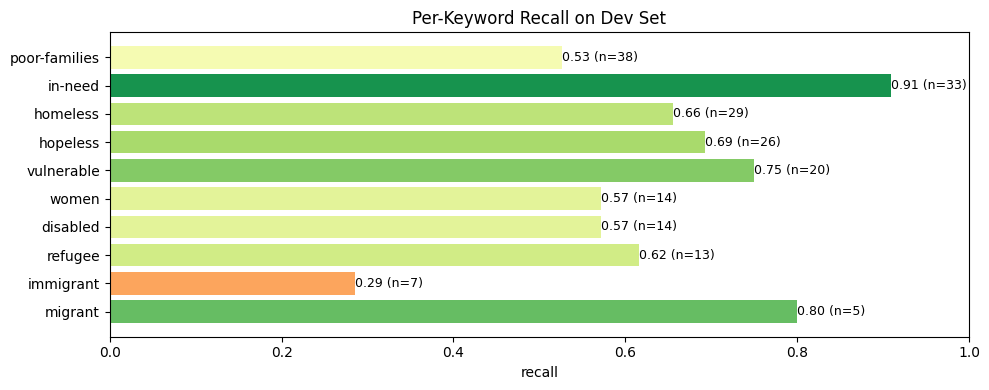

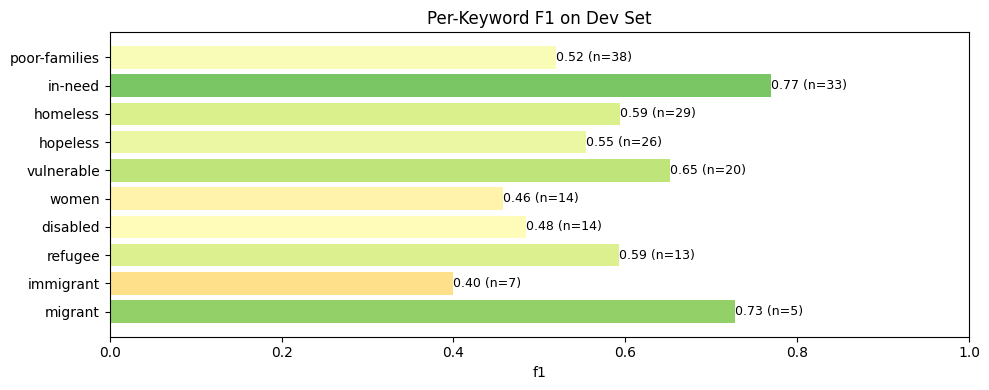

In [39]:
# Bar chart of per-keyword precision, recall, and F1
for metric in ["precision", "recall", "f1"]:
    valid_kw = kw_df.dropna(subset=[metric])
    cmap = plt.colormaps["RdYlGn"]
    fig, ax = plt.subplots(figsize=(10, max(4, len(valid_kw) * 0.4)))
    colors = cmap(valid_kw[metric].values)  # Red = low F1, green = high
    ax.barh(kw_df["keyword"], kw_df[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f"Per-Keyword {metric.capitalize()} on Dev Set")
    ax.set_xlim(0, 1)
    for i, (_, row) in enumerate(kw_df.iterrows()):
        ax.text(row[metric], i, f"{row[metric]:.2f} (n={int(row['n_pos'])})",
                va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/error_analysis_keyword_f1.png", dpi=300)
    plt.show()

## 7. Per-Category Breakdown

PCL paragraphs are annotated with one or more PCL categories
(e.g. `Authority_voice`, `Compassion`, `Shallow_solution`).
This reveals which *types* of patronising language the model catches.

                  category   n   recall  tp  fn
    The_poorer_the_merrier  11 0.545455   6   5
          Shallow_solution  36 0.611111  22  14
            Presupposition  62 0.661290  41  21
           Authority_voice  38 0.684211  26  12
Unbalanced_power_relations 142 0.711268 101  41
                Compassion 106 0.754717  80  26
                 Metaphors  52 0.788462  41  11


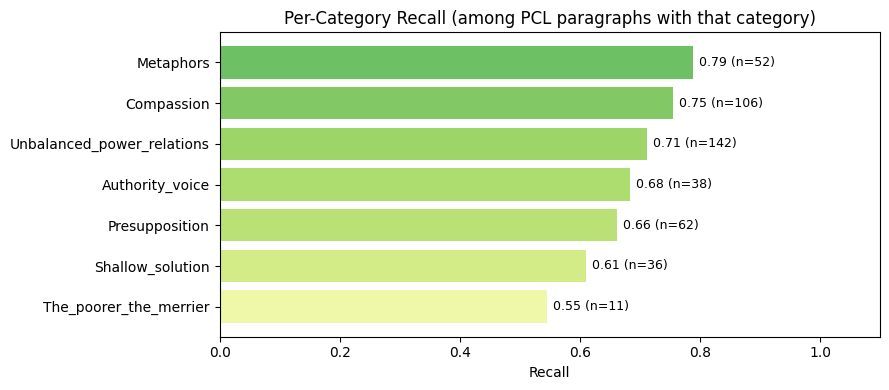

In [38]:
cat_stats = []
for cat in PCL_CATEGORIES:
    cat_samples = dev_df[dev_df[cat] == 1]
    n = len(cat_samples)
    if n == 0:
        continue
    tp = ((cat_samples["best_pred"] == 1) & (cat_samples["binary_label"] == 1)).sum()
    fn = ((cat_samples["best_pred"] == 0) & (cat_samples["binary_label"] == 1)).sum()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    cat_stats.append({"category": cat, "n": n, "recall": recall, "tp": tp, "fn": fn})

cat_df = pd.DataFrame(cat_stats).sort_values("recall", ascending=True)
print(cat_df.to_string(index=False))

# Visualise
cmap = plt.colormaps["RdYlGn"]
fig, ax = plt.subplots(figsize=(9, 4))
colors = cmap(cat_df["recall"].values)
bars = ax.barh(cat_df["category"], cat_df["recall"], color=colors)
ax.set_xlabel("Recall")
ax.set_title("Per-Category Recall (among PCL paragraphs with that category)")
ax.set_xlim(0, 1.1)
for i, (_, row) in enumerate(cat_df.iterrows()):
    ax.text(row["recall"] + 0.01, i, f"{row['recall']:.2f} (n={row['n']})",
            va="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/error_analysis_category_recall.png", dpi=300)
plt.show()

## 8. Error vs Text Length & Confidence Analysis

Investigate whether the model struggles with short/long texts,
and analyse the confidence distribution of errors.

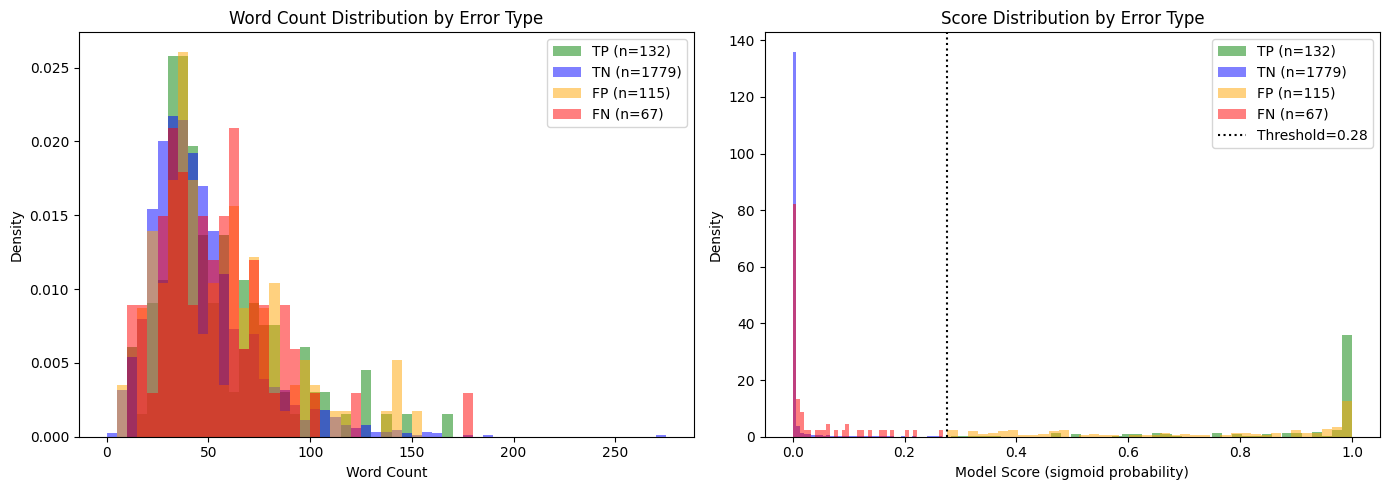

In [47]:
dev_df["text_len"] = dev_df["text"].str.len()
dev_df["word_count"] = dev_df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
types_to_colours =[("TP", "green"), ("TN", "blue"), ("FP", "orange"), ("FN", "red")] 

# Text length distribution by error type
word_bins = np.arange(0, dev_df["word_count"].max() + 5, 5)
for etype, color in types_to_colours:
    subset = dev_df[dev_df["error_type"] == etype]
    axes[0].hist(subset["word_count"], bins=word_bins, alpha=0.5, label=f"{etype} (n={len(subset)})",
                 color=color, density=True)
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Density")
axes[0].set_title("Word Count Distribution by Error Type")
axes[0].legend()

# Score distribution by error type
for etype, color in types_to_colours:
    subset = dev_df[dev_df["error_type"] == etype]
    axes[1].hist(subset["score"], bins=40, alpha=0.5, label=f"{etype} (n={len(subset)})",
                 color=color, density=True)
axes[1].axvline(x=BEST_THRESHOLD, color="black", linestyle=":", label=f"Threshold={BEST_THRESHOLD:.2f}")
axes[1].set_xlabel("Model Score (sigmoid probability)")
axes[1].set_ylabel("Density")
axes[1].set_title("Score Distribution by Error Type")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/error_analysis_length_confidence.png", dpi=300)
plt.show()

In [41]:
# --- Summary statistics of errors ---
summary = dev_df.groupby("error_type").agg(
    count=("text", "count"),
    mean_word_count=("word_count", "mean"),
    median_word_count=("word_count", "median"),
    mean_score=("score", "mean"),
    std_score=("score", "std"),
).round(2)
print(summary)

            count  mean_word_count  median_word_count  mean_score  std_score
error_type                                                                  
FN             67            53.01               51.0        0.04       0.06
FP            115            54.97               47.0        0.72       0.26
TN           1779            46.15               41.0        0.01       0.03
TP            132            54.48               45.0        0.90       0.18
